In [2]:
import tidy3d as td
import tidy3d.web as web
import matplotlib.pyplot as plt
import numpy as np
import gdstk
td.config.logging.level = "ERROR"

### Beam waist calculation

MFD of the fiber: 11.84 um

EFL of the lens: 5.95 mm

Free-space BD: 1.86 mm

EFL of the objective: 5.0 mm

Waist of the focused beam: 5 um

<Axes: title={'center': 'cross section at y=0.00 (μm)'}, xlabel='x (μm)', ylabel='z (μm)'>

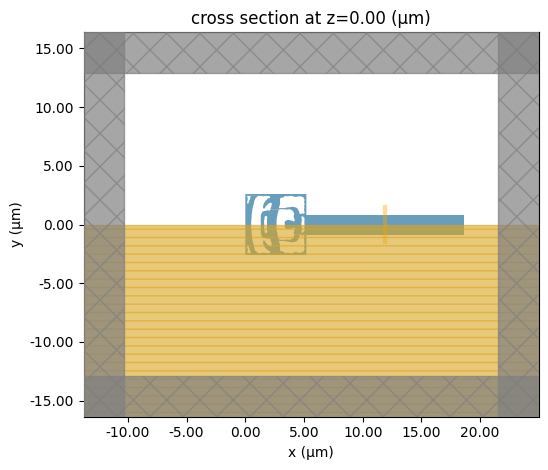

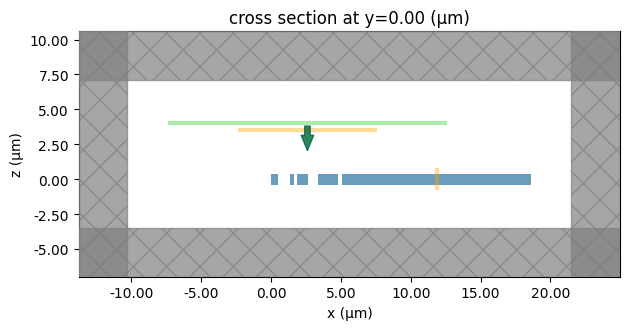

In [12]:
def initFreqParams():
    global Wvl0, WvlRange, Freq0, FreqRange, FreqBandWidth
    if Wvl0 is None and Freq0 is None: 
        raise ValueError('missing Wvl0 or Freq0')
    if WvlRange is None and FreqRange is None:
        raise ValueError('missing WvlRange or FreqRange')

    if Freq0 is None:
        Freq0 = C_c / Wvl0
    elif Wvl0 is None:
        Wvl0 = C_c / Freq0
    else:
        raise ValueError('assigning both Wvl0 and Freq0')

    if FreqRange is None:
        FreqRange = (C_c/WvlRange[1], C_c/WvlRange[0])
    elif WvlRange is None:
        WvlRange = (C_c/FreqRange[1], C_c/FreqRange[0])
    else:
        raise ValueError('assigning both Wvl0 and Freq0')

    FreqBandWidth = (FreqRange[1] - FreqRange[0]) * 3


def initStructs():
    global TDStructs
    lib = gdstk.read_gds(GDS_fp)
    cell = lib.top_level()[0]
    geo = td.Geometry.from_gds(
        gds_cell=cell, 
        slab_bounds=[-0.4,0.4],
        axis=2, 
        gds_layer=0
    )

    TDStructs = [
        td.Structure(
            geometry=geo,
            medium=TDMaterial,
            name='GratingCoupler',
        )
    ]


def initSources():
    global TDSources
    pulse = td.GaussianPulse(
        freq0=Freq0, 
        fwidth=FreqBandWidth,
        amplitude=1,
        phase=0,
    )
    TDSources.append(
        td.GaussianBeam(
            center=BeamCenter,
            size=BeamSize,
            angle_theta=BeamTiltDeg*np.pi/180,
            pol_angle=np.pi/2,
            direction='-',
            waist_radius=BeamWaist,
            waist_distance=-BeamDistance,
            source_time=pulse,
            name='GaussianBeam',
        )
    )
    return TDSources


def initMonitors():
    global TDMonitors

    # name = 'input_field'
    # TDMonitors.append(
    #     td.ModeMonitor(
    #         center=MonIn_Center,
    #         size=MonIn_Size,
    #         freqs=[Freq0],
    #         mode_spec=td.ModeSpec(num_modes=1),
    #         name=name,
    #     )
    # )

    # name = 'output_field'
    # TDMonitors.append(
    #     td.ModeMonitor(
    #         center=MonOut_Center,
    #         size=MonOut_Size,
    #         freqs=[Freq0],
    #         mode_spec=td.ModeSpec(num_modes=1),
    #         name=name,
    #     )
    # )

    # name = 'cross_section_z'
    # TDMonitors.append(
    #     td.FieldMonitor(
    #         center=MonCroSecZ_Center,
    #         size=MonCroSecZ_Size,
    #         freqs=[Freq0],
    #         name=name,
    #     )
    # )

    # name = 'cross_section_x'
    # TDMonitors.append(
    #     td.FieldMonitor(
    #         center=MonCroSecX_Center,
    #         size=MonCroSecX_Size,
    #         freqs=[Freq0],
    #         name=name,
    #     )
    # )

    name = "flux_in"
    TDMonitors.append(
        td.FluxMonitor(
            center=MonIn_Center,
            size=MonIn_Size,
            freqs=[Freq0],
            name=name,
            normal_dir='-'
        )
    )

    name = "flux_out"
    TDMonitors.append(
        td.FluxMonitor(
            center=MonOut_Center,
            size=MonOut_Size,
            freqs=[Freq0],
            name=name,
            normal_dir='+'
        )
    )

    return TDMonitors
    

def initSim():
    global TDSim
    TDBoundarySpec = td.BoundarySpec.all_sides(td.PML())
    TDGridSpec = td.GridSpec.auto(wavelength=Wvl0, min_steps_per_wvl=GridStepsPerWvl) 

    Sim_L = BeamSize[0]/2 + CouplerSize/2 + WaveguideLength + SimPadding_L
    Sim_W = BeamSize[1] + SimPadding_W
    Sim_H = BeamDistance + Thickness + SimPadding_H
    SimCenter_X = (CouplerSize + WaveguideLength - BeamSize[0]/2 + CouplerSize/2) / 2
    SimCenter_Y = 0
    SimCenter_Z = (BeamDistance - Thickness/2) / 2

    TDSim = td.Simulation(
        center=(SimCenter_X, SimCenter_Y, SimCenter_Z),
        size=(Sim_L, Sim_W, Sim_H),
        structures=TDStructs,
        sources=TDSources,
        monitors=TDMonitors,
        grid_spec=TDGridSpec,
        boundary_spec=TDBoundarySpec,
        symmetry=Symmetry,
        run_time=RunTime,
        shutoff=1e-5,
    )
    return TDSim


C_c = td.C_0
C_fs = 1e-15
C_THz = 1e12

Wvl0 = 2.9013670                    # center wavelength in um, length scale of the system
WvlRange = (2.8, 3.0)               # Wavelength range

Freq0 = None                        # center frequency
FreqRange = None                    # frequency range

initFreqParams()

TDMaterial = td.Medium.from_nk(n=2.036, k=0, freq=Freq0)  # 2.0124

#======================================================================
GDS_fp = './grating_coupler.gds'

CouplerSize = 5.2
WaveguideLength = 13.396
WaveguideWidth = 1.7
Thickness = 0.8

ORIGIN_X = CouplerSize/2
ORIGIN_Y = 0
ORIGIN_Z = 0
ORIGIN = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z)
CENTER = ((CouplerSize+WaveguideLength)/2, 0, 0)

TDStructs = []
initStructs()

#======================================================================
BeamWaist = 5
BeamDistance = 4
BeamSize = (4*BeamWaist, 4*BeamWaist, 0)
BeamCenter = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z+BeamDistance)
BeamTiltDeg = 0

TDSources = []
initSources()

#======================================================================
MonIn_Center = (ORIGIN_X, ORIGIN_Y, ORIGIN_Z+3.5)
MonIn_Size = (2*BeamWaist,2*BeamWaist,0)

MonOut_Center = (CouplerSize+WaveguideLength/2, ORIGIN_Y, ORIGIN_Z)
MonOut_Size = (0,WaveguideWidth*2,Thickness*2)

MonCroSecZ_Center = ((CouplerSize+WaveguideLength)/2, ORIGIN_Y, ORIGIN_Z+Thickness/1.9)
MonCroSecZ_Size = (CouplerSize+WaveguideLength, CouplerSize, 0)

MonCroSecX_Center = MonOut_Center
MonCroSecX_Size = MonOut_Size

TDMonitors = []
initMonitors()

#======================================================================
SimPadding_L = Wvl0 * 2
SimPadding_W = Wvl0 * 2
SimPadding_H = Wvl0 * 2
# SimSize = (Sim_L, Sim_W, Sim_H)  # simulation domain size

Symmetry = (0, -1, 0)               # parity of field about 3 planes
GridStepsPerWvl = 10                # spatial grid step of simulation in wavelength
RunTime = 1000 * C_fs

TDSim = None
initSim()
TDSim.plot(z=0)
TDSim.plot(y=0)

In [13]:
from datetime import datetime as dt
name = f'Tantala_grating_coupler--{dt.now().strftime("%Y%m%d_%H%M%S")}'
job = web.Job(simulation=TDSim, task_name=name, verbose=False)
est_cost = web.estimate_cost(job.task_id)
print(f'Estimate Cost: {est_cost}')
sim_data = job.run(path=f'data/{name}.hdf5')    
# sim_data = td.SimulationData.from_hdf5('data/tantala-pcc-v1-test.hdf5')

13:13:32 Mountain Daylight Time Estimated FlexCredit cost: 0.025. Minimum cost  
                                depends on task execution details. Use          
                                'web.real_cost(task_id)' to get the billed      
                                FlexCredit cost after a simulation run.

Estimate Cost: 0.025


In [14]:
sim_data['flux_in'].flux, sim_data['flux_out'].flux

(<xarray.FluxDataArray (f: 1)> Size: 4B
 array([0.83034515], dtype=float32)
 Coordinates:
   * f        (f) float64 8B 1.033e+14
 Attributes:
     units:      W
     long_name:  flux,
 <xarray.FluxDataArray (f: 1)> Size: 4B
 array([0.11032411], dtype=float32)
 Coordinates:
   * f        (f) float64 8B 1.033e+14
 Attributes:
     units:      W
     long_name:  flux)

<Axes: title={'center': 'cross section at x=11.90 (μm)'}, xlabel='y (μm)', ylabel='z (μm)'>

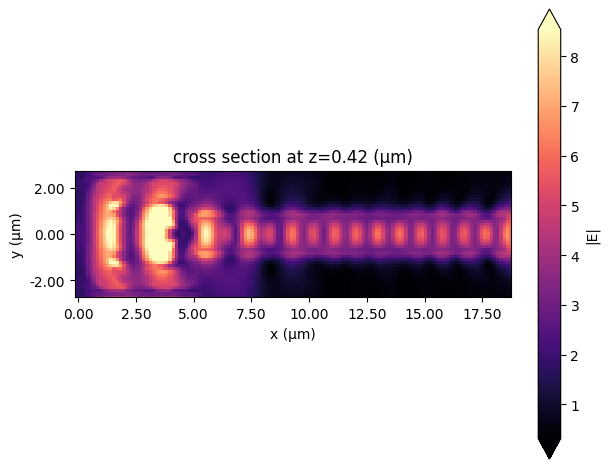

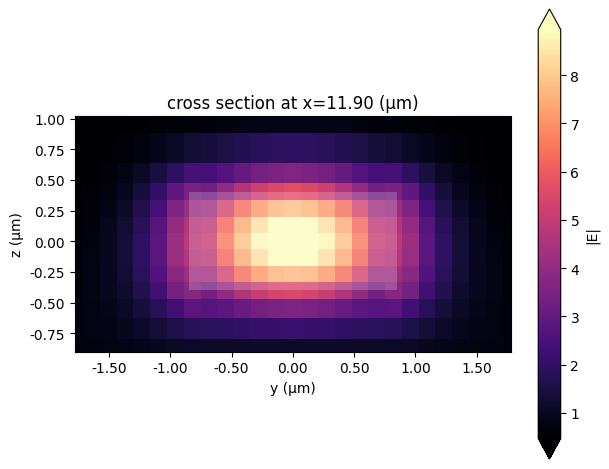

In [181]:
sim_data.plot_field(field_monitor_name='cross_section_z', field_name='E', val='abs')
sim_data.plot_field(field_monitor_name='cross_section_x', field_name='E', val='abs')

In [182]:
input_power = np.abs(sim_data['input_field'].amps.sel(direction='-', mode_index=0).values[0])**2
output_power = np.abs(sim_data['output_field'].amps.sel(direction='+', mode_index=0).values[0])**2
print(f'Input Power:\t{input_power} W')
print(f'Output Power:\t{output_power} W')
print(f'Efficiency:\t{output_power/input_power*100:.2f} %')

Input Power:	0.5678988247612833 W
Output Power:	0.11780315765947731 W
Efficiency:	20.74 %


In [163]:
input_power = np.abs(sim_data['input_field'].amps.sel(direction='-', mode_index=0).values[0])**2
output_power = np.abs(sim_data['output_field'].amps.sel(direction='+', mode_index=0).values[0])**2
print(f'Input Power:\t{input_power} W')
print(f'Output Power:\t{output_power} W')
print(f'Efficiency:\t{output_power/input_power*100:.2f} %')

Input Power:	0.5918052558247835 W
Output Power:	0.3122315003764997 W
Efficiency:	52.76 %
